In [1]:
%pip install pandas seaborn matplotlib torch transformers sentencepiece protobuf scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 48.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [3]:
!unzip archive.zip

Archive:  archive.zip
   creating: commonsense/
   creating: commonsense/models/
   creating: commonsense/data/
  inflating: commonsense/data/commonsense_test.csv  
  inflating: commonsense/data/commonsense_ambig.csv  
  inflating: commonsense/data/commonsense_train.csv  
  inflating: commonsense/data/commonsense_test_hard.csv  
   creating: commonsense/results/
   creating: deontology/
   creating: deontology/models/
   creating: deontology/data/
  inflating: deontology/data/deontology_test_hard.csv  
  inflating: deontology/data/deontology_test.csv  
  inflating: deontology/data/deontology_train.csv  
   creating: deontology/results/
   creating: justice/
   creating: justice/models/
   creating: justice/data/
  inflating: justice/data/justice_test_hard.csv  
  inflating: justice/data/justice_train.csv  
  inflating: justice/data/justice_test.csv  
   creating: justice/results/
   creating: utilitarianism/
   creating: utilitarianism/models/
   creating: utilitarianism/data/
  inflat

In [4]:
%pwd

'/content'

## Choose task (value)

In [5]:
tasks = [
    "commonsense",
    "deontology",
    "justice",
    "utilitarianism",
    "virtue",
]

task = "commonsense"
# task = "deontology"
# task = "justice"
# task = "utilitarianism"
# task = "virtue"

## Data exploration

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from typing import Tuple
from itertools import product
from torch.utils.data import DataLoader
from utils import load_model, load_process_data, train, evaluate

In [7]:
# Load datasets
ds_test_hard = pd.read_csv(f"{task}/data/{task}_test_hard.csv")
ds_test = pd.read_csv(f"{task}/data/{task}_test.csv")
ds_train = pd.read_csv(f"{task}/data/{task}_train.csv")

# Combine labeled datasets for general stats
datasets = {"train": ds_train, "test": ds_test, "test_hard": ds_test_hard}

In [8]:
# Check missing values
for name, df in datasets.items():
    print(f"Missing values in {name}:\n{df.isnull().sum()}\n")

Missing values in train:
label       0
input       0
is_short    0
edited      0
dtype: int64

Missing values in test:
label       0
input       0
is_short    0
edited      0
dtype: int64

Missing values in test_hard:
label       0
input       0
is_short    0
edited      0
dtype: int64



Label distribution in train:
label
0    0.543206
1    0.456794
Name: proportion, dtype: float64

Label distribution in test:
label
0    0.532561
1    0.467439
Name: proportion, dtype: float64

Label distribution in test_hard:
label
1    0.527497
0    0.472503
Name: proportion, dtype: float64



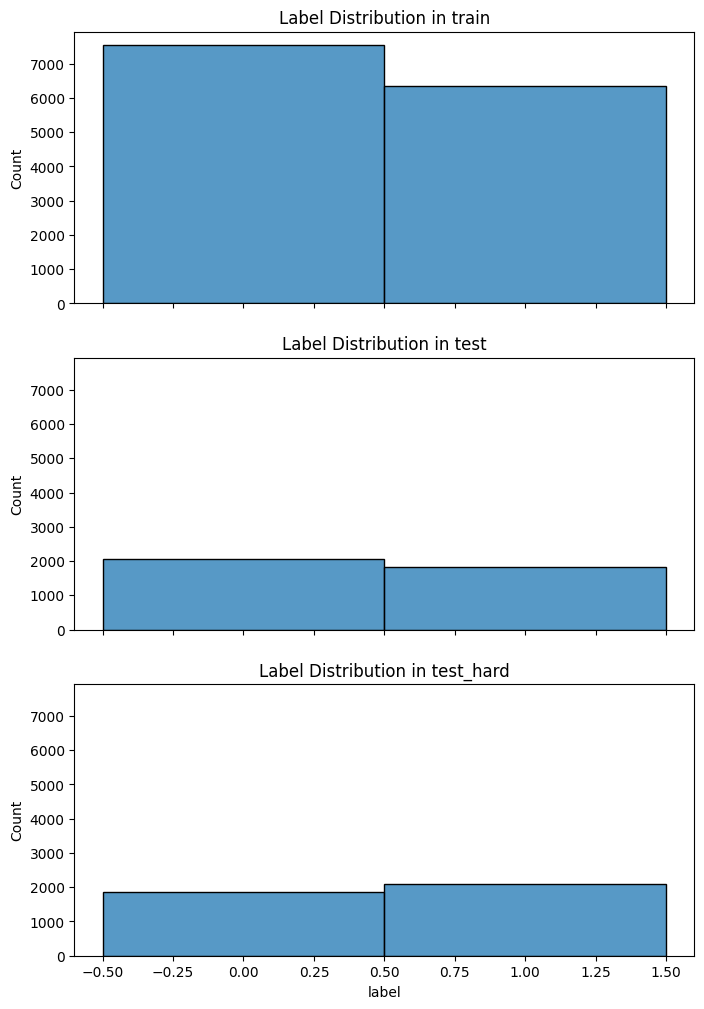

In [9]:
# Label distribution

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 12), sharex=True, sharey=True)

for (name, df), ax in zip(datasets.items(), axes):
    print(
        f"Label distribution in {name}:\n{df['label'].value_counts(normalize=True)}\n"
    )
    sns.histplot(df["label"], discrete=True, ax=ax)
    ax.set_title(f"Label Distribution in {name}")
plt.show()

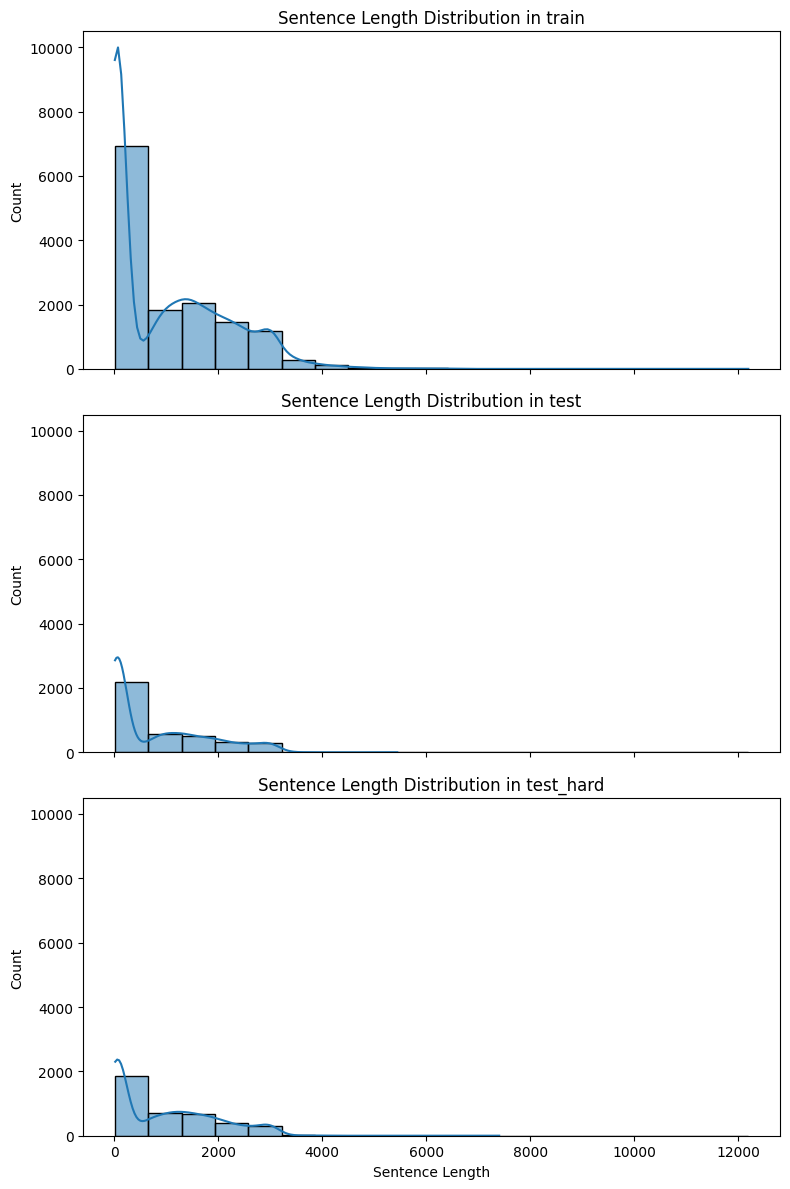

In [10]:
# Compute global min and max length for consistent binning
all_lengths = []
for df in datasets.values():
    if "util" in task or "deontology" in task:
        df["length"] = (df.iloc[:, 1] + "[SEP]" + df.iloc[:, 2]).apply(len)
    else:
        df["length"] = (df.iloc[:, 1]).apply(len)
    all_lengths.extend(df["length"])

min_length = min(all_lengths)
max_length = max(all_lengths)

# Define shared bins
num_bins = 20
bins = np.linspace(min_length, max_length, num_bins)

# Create figure and subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 12), sharex=True, sharey=True)

# Plot sentence length distributions in subplots
for i, (name, df) in enumerate(datasets.items()):

    sns.histplot(df["length"], bins=bins, kde=True, ax=axes[i])  # Use shared bins
    # axes[i].set_yscale("log")  # Log scale for y-axis
    axes[i].set_title(f"Sentence Length Distribution in {name}")
    # axes[i].set_ylabel("Count (log scale)")

# Shared x-label for all plots
axes[-1].set_xlabel("Sentence Length")
axes[-1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Choose model

In [11]:
models = [
    # "bert-base-uncased",
    "microsoft/deberta-v3-base",  # TODO use
    "distilbert-base-uncased",  # TODO use
    "t5-small",  # TODO use
    "albert-base-v2",  # TODO use
    # "distilbert-base-multilingual-cased",
    # "distilroberta-base",
    # "t5-base",
    # "albert-large-v2",
    # "xlnet-base-cased",
    # "google/electra-small-discriminator",
    # "microsoft/deberta-v3-base,
    # "facebook/bart-base",
    # "EleutherAI/gpt-j-6B", # too big
]

now = datetime.now()
hour, minute, second = now.hour, now.minute, now.second
res_file = f"{task}/results/r_{hour}_{minute}_{second}.csv"
with open(res_file, "w") as f:
    f.write("model,lr,batch_size,n_epoch,test_hard_accuracy,test_accuracy\n")

## Fine tuning

In [12]:
def run_experiment(
    model_name: str, lr: float, batch_size: int, n_epoch: int
) -> Tuple[float, float]:

    model, optimizer = load_model(model_name, lr, weight_decay=0.01)

    # data
    data_dir = Path(f"{task}/data")
    train_data = load_process_data(model_name, data_dir, task, "train")
    test_hard_data = load_process_data(model_name, data_dir, task, "test_hard")
    test_data = load_process_data(model_name, data_dir, task, "test")

    train_dataloader = DataLoader(
        train_data,
        batch_size=batch_size,
        shuffle=True,
    )
    test_hard_dataloader = DataLoader(
        test_hard_data,
        batch_size=batch_size,
        shuffle=False,
    )
    test_dataloader = DataLoader(
        test_data,
        batch_size=batch_size,
        shuffle=False,
    )

    test_hard_acc = 0
    test_acc = 0
    for epoch in range(1, n_epoch + 1):
        print()
        train(model, optimizer, train_dataloader, epoch, task)
        print("\ntest hard set:")
        test_hard_acc = evaluate(model, test_hard_dataloader)
        print("\ntest set:")
        test_acc = evaluate(model, test_dataloader)

    save_path = Path(
        f"{task}/models/{task}_{hour}_{minute}_{second}_{model_name}_{lr}_{batch_size}_{n_epoch}.hf"
    )
    print("SAVING to", save_path)
    model.save_pretrained(str(save_path))

    return (
        test_hard_acc,
        test_acc,
    )

In [ ]:
lrs = [1e-5, 3e-5]
batch_sizes = [64]  # TODO as big as possible
epochs = [2, 4]  # TODO [2,4]

for model, lr, bs, n_epoch in product(models, lrs, batch_sizes, epochs):

    test_hard_acc, test_acc = run_experiment(model, lr, bs, n_epoch)

    with open(res_file, "a") as f:
        f.write(f"{model},{lr},{bs},{n_epoch},{test_hard_acc},{test_acc}\n")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Pretrained model "microsoft/deberta-v3-base" loaded


/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
/usr


Train Epoch: 1 [0/13910] Loss: 0.700068

test hard set:
Accuracy: 0.5212

test set:
Accuracy: 0.7601

Train Epoch: 2 [0/13910] Loss: 0.490596


In [ ]:
!zip -r archiveDown commonsense/ deontology/ justice/ utilitarianism/ virtue/ utils.py

	zip warning: name not matched: commonsense/
	zip warning: name not matched: deontology/
	zip warning: name not matched: justice/
	zip warning: name not matched: utilitarianism/
	zip warning: name not matched: virtue/
	zip warning: name not matched: utils.py

zip error: Nothing to do! (try: zip -r archiveDown . -i commonsense/ deontology/ justice/ utilitarianism/ virtue/ utils.py)
